### Importando Bibliotecas

In [1]:
import importlib

In [26]:
import database_setup
import interactive_form
import social_media_updater
import data_importer
importlib.reload(database_setup)
importlib.reload(interactive_form)
importlib.reload(social_media_updater)
importlib.reload(data_importer)

from database_setup import setup_database
from interactive_form import create_furia_form
from social_media_updater import main_social_update
from data_importer import import_data

### Criando Banco de dados e Tabelas

In [27]:
# Executar setup
if setup_database():
    print("Banco de dados pronto para uso!")
else:
    print("Falha na configuração do banco")

Verificando banco de dados...
Criando banco de dados...
Banco 'user-data' criado

Criando tabelas...
Query executada com sucesso!
Tabela Usuarios criada/verificada
Query executada com sucesso!
Tabela Redes_Sociais criada/verificada
Query executada com sucesso!
Tabela Enderecos criada/verificada

Setup completo!
Banco de dados pronto para uso!


### Inserindo dados de teste

In [38]:
import_data()

100 registros inseridos em usuarios
82 registros inseridos em enderecos
93 registros inseridos em redes_sociais


### Formulário

In [10]:
form = create_furia_form()
display(form)

### Rede Sociais

In [42]:
main_social_update()

### Análise dos fãs

Importações necessárias

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import db_utils
importlib.reload(db_utils)
from db_utils import create_connection

Configuração do estilo dos gráficos

In [3]:
FURIA_PALETTE = ['#000000', '#FFFFFF', '#FFFFFF']
plt.style.use('dark_background')
sns.set_palette(FURIA_PALETTE)

Conexão com o banco de dados

In [4]:
conn = create_connection(dbname="user-data", user="admin", password="admin", host="postgres", port="5432")

ANÁLISE GEOGRÁFICA DOS FÃS


 ANÁLISE GEOGRÁFICA DOS FÃS


/tmp/ipykernel_410/1737287318.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_geo = pd.read_sql(query, conn)


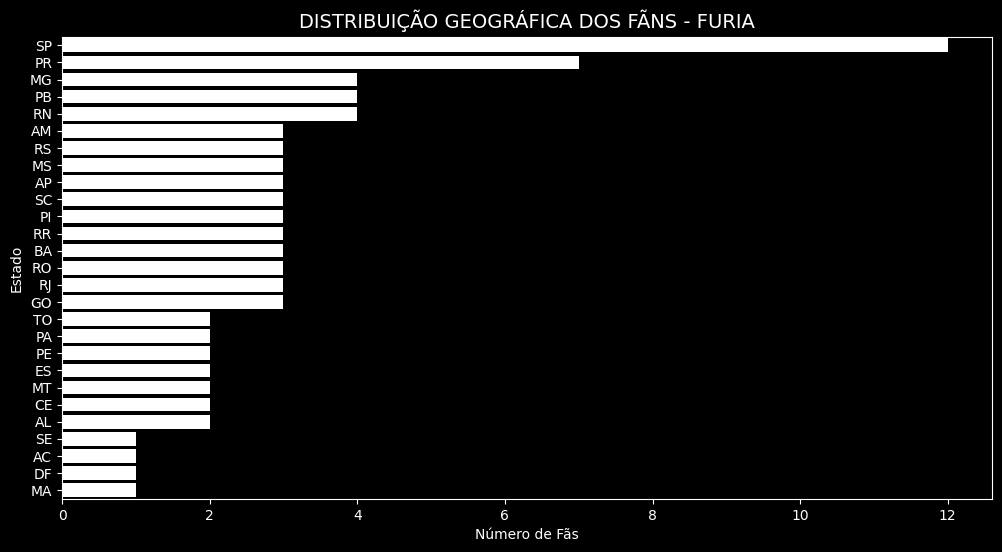

In [6]:
print("\n ANÁLISE GEOGRÁFICA DOS FÃS")
query = """
    SELECT e.estado, COUNT(*) as total
    FROM usuarios u
    JOIN enderecos e ON u.id_usuario = e.id_usuario
    GROUP BY e.estado
    ORDER BY total DESC
"""
df_geo = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(x='total', y='estado', data=df_geo, color=FURIA_PALETTE[1])
plt.title('DISTRIBUIÇÃO GEOGRÁFICA DOS FÃNS - FURIA', fontsize=14, color='white')
plt.xlabel('Número de Fãs', color='white')
plt.ylabel('Estado', color='white')
plt.show()

PRODUTOS MAIS DESEJADOS


PRODUTOS MAIS DESEJADOS


/tmp/ipykernel_919/2493892947.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_produtos = pd.read_sql(query, conn)


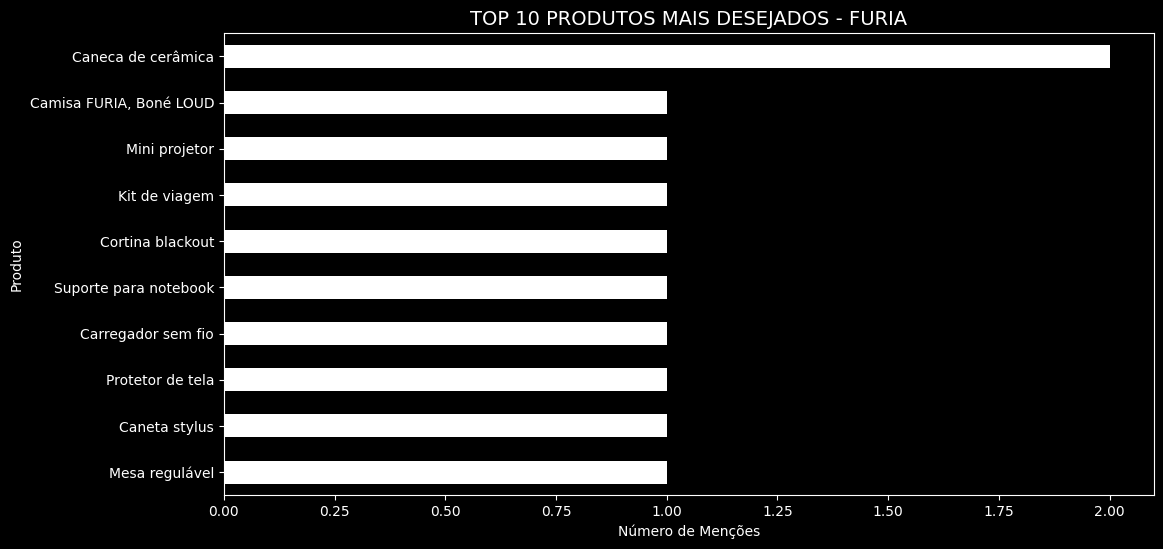

In [60]:
print("\nPRODUTOS MAIS DESEJADOS")
query = "SELECT produtos_desejados FROM usuarios"
df_produtos = pd.read_sql(query, conn)

all_products = df_produtos['produtos_desejados'].str.split(';').explode()
product_counts = all_products.value_counts().head(10)

plt.figure(figsize=(12,6))
product_counts.plot(kind='barh', color=FURIA_PALETTE[1])
plt.title('TOP 10 PRODUTOS MAIS DESEJADOS - FURIA', fontsize=14, color='white')
plt.xlabel('Número de Menções', color='white')
plt.ylabel('Produto', color='white')
plt.gca().invert_yaxis()
plt.show()

HISTÓRICO DE COMPRAS ESPORTS


 COMPRAS DE PRODUTOS ESPORTS


/tmp/ipykernel_410/965753425.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_compras = pd.read_sql(query, conn)


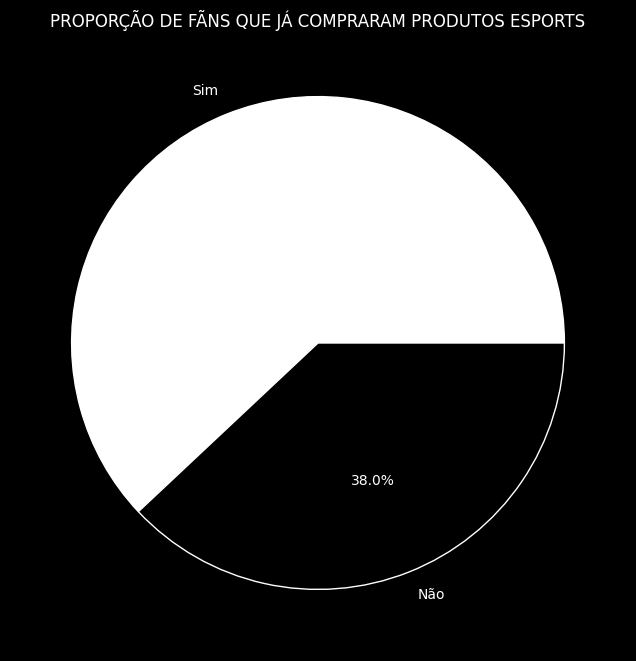

In [7]:
print("\n COMPRAS DE PRODUTOS ESPORTS")
query = "SELECT compras_esports FROM usuarios" 
df_compras = pd.read_sql(query, conn)

plt.figure(figsize=(8,8))
df_compras['compras_esports'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    colors=[FURIA_PALETTE[1], FURIA_PALETTE[0]]
)
plt.title('PROPORÇÃO DE FÃNS QUE JÁ COMPRARAM PRODUTOS ESPORTS', color='white', fontsize=12)
plt.ylabel('')
plt.show()

JOGOS FAVORITOS



 JOGOS MAIS POPULARES


/tmp/ipykernel_919/1882496940.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_jogos = pd.read_sql(query, conn)


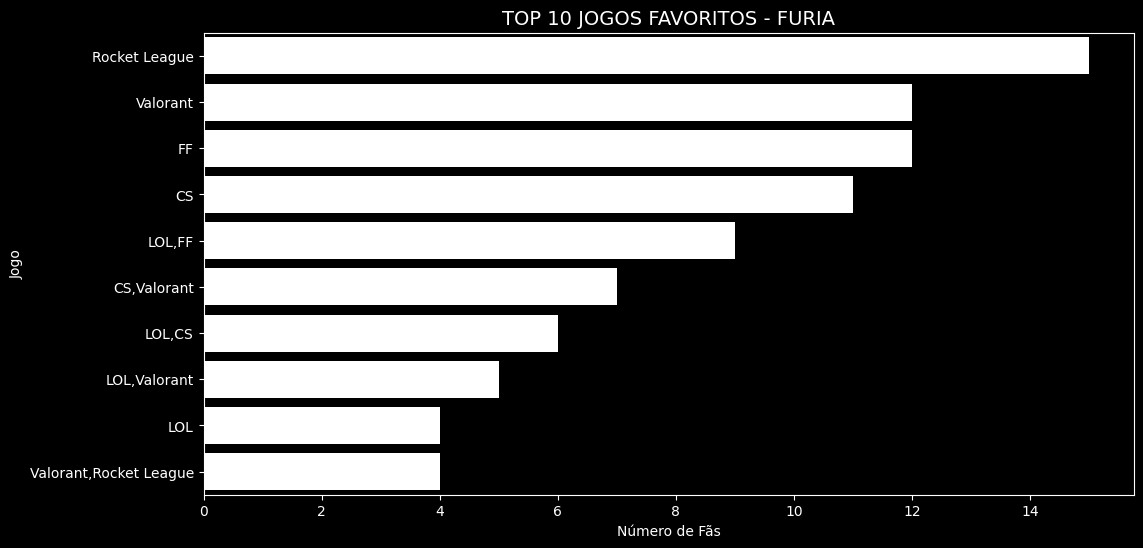

In [66]:
print("\n JOGOS MAIS POPULARES")
query = "SELECT jogos_favoritos FROM usuarios"
df_jogos = pd.read_sql(query, conn)

all_games = df_jogos['jogos_favoritos'].str.split(';').explode()
game_counts = all_games.value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=game_counts.values, y=game_counts.index, color=FURIA_PALETTE[1])
plt.title('TOP 10 JOGOS FAVORITOS - FURIA', fontsize=14, color='white')
plt.xlabel('Número de Fãs', color='white')
plt.ylabel('Jogo', color='white')
plt.show()

Fechar conexão

In [ ]:
conn.close()